# Categorical Encoding — the full catalogue, and how to pick one

01 Core Python · 02 Pandas · 03 Cleaning · **▶ 04 Transformation** · 05 Feature Engineering · 06 Regression · 07 Model Prep · 08 Case Studies

`04_Data_Transformation/02_categorical_encoding_catalogue.ipynb`

---

### In one paragraph (no jargon)

Models do arithmetic; they cannot multiply by the word "Mumbai". Encoding turns labels into numbers, and the method you choose matters more than people expect. Label-encode a nominal column and you've told the model that South (2) is somehow twice North (1). One-hot encode a column with 5,000 postcodes and you've created 5,000 columns. This notebook works through every standard technique with its trade-off, then gives you a decision rule.

### After this notebook you can

- Apply label, ordinal, one-hot, dummy, frequency, target, binary and hashing encoding
- Choose the right one from the column's type and cardinality
- Avoid the dummy-variable trap and target leakage
- Explain the cost of each method in columns and in interpretability


### What's inside

1. Setup
2. Label encoding
3. Ordinal encoding
4. One-hot encoding
5. Dummy encoding (drop_first)
6. Frequency encoding
7. Target encoding with smoothing
8. Binary encoding
9. Hashing encoding
10. The real cost of each technique
11. Decision guide
12. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Categorical variable** | A column of labels rather than numbers: `Male/Female`, `North/South`, `Gold/Silver/Bronze`. |
| **Nominal** | Categories with **no** natural order — city, colour, payment method. |
| **Ordinal** | Categories **with** an order — Low < Medium < High, 1st Class < 2nd Class. |
| **Cardinality** | How many distinct categories a column has. 2 is low, 5,000 (postcodes) is high. |
| **Encoding** | Converting labels into numbers, because most models can only do arithmetic. |
| **One-hot** | One new yes/no column per category. Safe, but wide. |
| **Dummy variable trap** | Keeping all one-hot columns makes them perfectly predictable from each other, which breaks regression. Dropping one fixes it. |
| **Target leakage** | Accidentally letting information from the answer column into a feature, so the model looks brilliant in training and fails in reality. |
| **Discretisation / binning** | Turning a number into bands: age 34 → "30–39". |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------------------------
# `category_encoders` provides Binary, Hashing and Target encoders. It is an
# optional library, so if it isn't installed we supply equivalents written in
# plain pandas below. Seeing the implementation is arguably more instructive
# than importing it — each is only a few lines.
# ---------------------------------------------------------------------------
try:
    import category_encoders as ce
    print("Using the category_encoders library.")
except ImportError:
    print("category_encoders not installed - using the built-in equivalents below.")

    class _BinaryEncoder:
        """Label-encode, then write the label number in binary across several columns.

        WHY: k categories need only log2(k) columns instead of one-hot's k.
        """
        def __init__(self, cols=None, **kw):
            self.cols, self.maps_ = cols, {}

        def fit(self, X, y=None):
            X = pd.DataFrame(X).copy()
            for col in (self.cols or X.columns):
                self.maps_[col] = {v: i for i, v in enumerate(sorted(X[col].astype(str).unique()))}
            return self

        def transform(self, X):
            X = pd.DataFrame(X).copy()
            out = pd.DataFrame(index=X.index)
            for col, mapping in self.maps_.items():
                codes = X[col].astype(str).map(mapping).fillna(0).astype(int).to_numpy()
                width = max(1, int(np.ceil(np.log2(max(len(mapping), 2)))))
                for bit in range(width):
                    out[f"{col}_{bit}"] = np.bitwise_and(np.right_shift(codes, bit), 1)
            return out

        def fit_transform(self, X, y=None):
            return self.fit(X, y).transform(X)

    class _HashingEncoder:
        """Hash each category into one of n fixed buckets.

        WHY: the output width is fixed in advance, however many categories appear -
        so an unseen category at prediction time can never break anything.
        COST: two categories can land in the same bucket (a 'collision').
        """
        def __init__(self, n_components=8, cols=None, **kw):
            self.n, self.cols = n_components, cols

        def fit(self, X, y=None):
            return self

        def transform(self, X):
            X = pd.DataFrame(X).copy()
            out = pd.DataFrame(0, index=X.index, columns=[f"col_{i}" for i in range(self.n)])
            for col in (self.cols or X.columns):
                for i, value in enumerate(X[col].astype(str)):
                    out.iloc[i, hash(value) % self.n] += 1
            return out

        def fit_transform(self, X, y=None):
            return self.fit(X, y).transform(X)

    class _TargetEncoder:
        """Replace each category with the mean of the target for that category,
        blended toward the overall mean so rare categories aren't trusted too far."""
        def __init__(self, cols=None, smoothing=10.0, **kw):
            self.cols, self.smoothing, self.maps_, self.prior_ = cols, smoothing, {}, 0.0

        def fit(self, X, y):
            X, y = pd.DataFrame(X).copy(), pd.Series(y).reset_index(drop=True)
            self.prior_ = y.mean()
            for col in (self.cols or X.columns):
                grouped = y.groupby(X[col].astype(str).reset_index(drop=True))
                counts, means = grouped.count(), grouped.mean()
                # smoothing: small groups are pulled toward the overall mean
                self.maps_[col] = ((counts * means + self.smoothing * self.prior_)
                                   / (counts + self.smoothing))
            return self

        def transform(self, X):
            X = pd.DataFrame(X).copy()
            out = pd.DataFrame(index=X.index)
            for col, mapping in self.maps_.items():
                out[col] = X[col].astype(str).map(mapping).fillna(self.prior_)
            return out

        def fit_transform(self, X, y=None):
            return self.fit(X, y).transform(X)

    class _CE:
        BinaryEncoder = _BinaryEncoder
        HashingEncoder = _HashingEncoder
        TargetEncoder = _TargetEncoder

    ce = _CE()

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_customer_data():
    """Exact copy of customer_data.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Customer_ID,Age,Gender,Income,Purchase_Amount,Region
1,55.0,Male,70000.0,2400.0,West
2,45.0,Male,65000.0,1900.0,North
3,31.0,Male,30000.0,2400.0,East
4,59.0,Female,50000.0,1400.0,
5,24.0,Female,70000.0,4000.0,East
6,37.0,,20000.0,3900.0,West
7,55.0,Male,25000.0,3800.0,South
8,35.0,Female,70000.0,2200.0,West
9,39.0,Female,,2300.0,East
10,27.0,Male,,2100.0,West
11,27.0,Female,75000.0,4400.0,North
12,40.0,Female,25000.0,1700.0,North
13,52.0,Female,65000.0,1800.0,North
14,56.0,Male,35000.0,3400.0,East
15,40.0,Male,70000.0,,West
16,19.0,Female,25000.0,600.0,West
17,38.0,Female,,1900.0,North
18,18.0,Male,,2600.0,West
19,40.0,Male,50000.0,1400.0,South
20,46.0,,60000.0,1500.0,South
21,54.0,Male,65000.0,1300.0,North
22,18.0,Female,70000.0,3500.0,West
23,37.0,Female,75000.0,1900.0,North
24,49.0,Female,75000.0,1100.0,East
25,28.0,Female,70000.0,4100.0,West
26,38.0,Male,20000.0,1500.0,North
27,41.0,Female,75000.0,2700.0,East
28,43.0,Female,25000.0,3100.0,South
29,58.0,Male,20000.0,1100.0,South
30,44.0,Male,25000.0,3100.0,East
31,32.0,,45000.0,3900.0,South
32,31.0,Female,,2900.0,East
33,19.0,Male,60000.0,1100.0,East
34,53.0,,50000.0,3100.0,East
35,23.0,,75000.0,3100.0,West
36,37.0,Female,60000.0,4000.0,East
37,25.0,Female,60000.0,4400.0,East
38,55.0,Male,60000.0,3900.0,East
39,34.0,Male,20000.0,3000.0,South
40,20.0,Female,25000.0,2000.0,South
41,41.0,Female,55000.0,1200.0,West
42,30.0,Female,45000.0,3600.0,East
43,25.0,Male,30000.0,2300.0,South
44,42.0,Female,60000.0,1600.0,East
45,18.0,Female,35000.0,3100.0,South
46,36.0,,20000.0,3200.0,West
47,44.0,Female,75000.0,1600.0,North
48,23.0,Female,65000.0,4900.0,South
49,24.0,Female,75000.0,3800.0,South
50,51.0,Male,50000.0,900.0,East
51,30.0,,30000.0,2100.0,West
52,33.0,,55000.0,800.0,North
53,52.0,Male,35000.0,2800.0,West
54,56.0,Male,75000.0,500.0,North
55,20.0,Female,55000.0,1300.0,West
56,18.0,Male,30000.0,3300.0,North
57,22.0,,60000.0,4800.0,North
58,58.0,Male,35000.0,800.0,East
59,20.0,Male,55000.0,3600.0,
60,45.0,Female,50000.0,,West
61,34.0,Male,25000.0,2100.0,East
62,42.0,Male,,3500.0,West
63,50.0,Female,25000.0,1400.0,North
64,26.0,Female,30000.0,2400.0,
65,52.0,Male,20000.0,2900.0,East
66,30.0,Female,,2800.0,West
67,47.0,Female,45000.0,2500.0,West
68,31.0,Female,50000.0,3000.0,West
69,24.0,Male,45000.0,1600.0,East
70,30.0,Female,35000.0,3600.0,East
71,39.0,,70000.0,3700.0,West
72,56.0,Female,,4400.0,South
73,37.0,,45000.0,3800.0,
74,32.0,Male,75000.0,,West
75,34.0,Male,45000.0,2400.0,North
76,40.0,Female,55000.0,900.0,West
77,42.0,Female,25000.0,3100.0,East
78,41.0,Female,55000.0,2000.0,West
79,57.0,Male,,800.0,West
80,45.0,Female,,3400.0,North
81,31.0,Female,30000.0,800.0,East
82,,Female,55000.0,4100.0,West
83,41.0,Male,40000.0,600.0,South
84,23.0,,75000.0,2600.0,East
85,25.0,Female,65000.0,4000.0,South
86,40.0,Male,25000.0,4000.0,East
87,,Female,,1300.0,East
88,24.0,Female,30000.0,1300.0,East
89,40.0,,70000.0,2200.0,South
90,27.0,Male,75000.0,2000.0,East
91,33.0,Female,55000.0,2400.0,North
92,24.0,Female,25000.0,1700.0,North
93,51.0,,70000.0,1200.0,North
94,51.0,Male,55000.0,4900.0,North
95,49.0,Male,45000.0,,East
96,21.0,Male,70000.0,4800.0,East
97,58.0,Male,30000.0,1600.0,West
98,55.0,Female,25000.0,700.0,North
99,57.0,Male,60000.0,,West
100,44.0,Male,35000.0,4300.0,West
101,23.0,Female,35000.0,3500.0,South
102,25.0,,25000.0,3700.0,West
103,24.0,Male,70000.0,3100.0,
104,28.0,Male,55000.0,3400.0,South
105,50.0,Female,30000.0,1100.0,South
106,49.0,Male,65000.0,4200.0,West
107,39.0,Male,35000.0,2900.0,West
108,40.0,Male,30000.0,3700.0,North
109,53.0,Male,35000.0,600.0,West
110,51.0,Female,45000.0,1500.0,West
111,56.0,Male,55000.0,,West
112,38.0,Female,45000.0,4700.0,West
113,43.0,Female,75000.0,800.0,West
114,51.0,Male,35000.0,3300.0,North
115,,Male,60000.0,3300.0,South
116,51.0,Male,60000.0,2000.0,East
117,53.0,Female,45000.0,2600.0,West
118,30.0,Male,60000.0,1800.0,South
119,19.0,Male,35000.0,4000.0,East
120,,Female,25000.0,2400.0,East
121,21.0,Male,45000.0,1700.0,East
122,42.0,Male,75000.0,500.0,West
123,30.0,Male,65000.0,1400.0,West
124,55.0,Male,65000.0,4200.0,East
125,43.0,Female,20000.0,4100.0,East
126,25.0,Male,70000.0,3700.0,South
127,31.0,Female,55000.0,4100.0,East
128,31.0,Male,60000.0,3700.0,South
129,42.0,Female,60000.0,2100.0,South
130,58.0,Male,70000.0,3300.0,East
131,29.0,Male,,1800.0,North
132,48.0,,75000.0,3000.0,South
133,55.0,Female,40000.0,3700.0,East
134,48.0,Female,45000.0,4100.0,South
135,20.0,Male,75000.0,3600.0,South
136,46.0,Male,50000.0,2700.0,West
137,53.0,Male,60000.0,1800.0,East
138,39.0,Female,55000.0,3300.0,North
139,55.0,Male,20000.0,4500.0,West
140,31.0,Female,65000.0,2000.0,East
141,59.0,Male,60000.0,800.0,West
142,45.0,,20000.0,3200.0,East
143,52.0,Female,35000.0,700.0,
144,29.0,Female,75000.0,1300.0,West
145,48.0,Male,35000.0,2000.0,West
146,23.0,Male,40000.0,1300.0,West
147,38.0,Female,25000.0,2000.0,North
148,44.0,Male,50000.0,2300.0,South
149,18.0,Male,75000.0,2700.0,West
150,58.0,,,800.0,East
151,22.0,Female,40000.0,3700.0,West
152,44.0,Male,30000.0,900.0,North
153,44.0,Male,,500.0,East
154,36.0,Male,45000.0,1600.0,South
155,46.0,Female,55000.0,4600.0,East
156,27.0,Male,75000.0,4600.0,East
157,44.0,Male,30000.0,1400.0,East
158,41.0,Male,30000.0,2600.0,East
159,55.0,Male,40000.0,1900.0,East
160,49.0,Female,70000.0,3400.0,South
161,,Male,25000.0,1400.0,West
162,43.0,,75000.0,1900.0,North
163,29.0,Male,70000.0,1100.0,East
164,57.0,Male,40000.0,700.0,East
165,19.0,Male,45000.0,4300.0,West
166,55.0,Male,65000.0,700.0,East
167,22.0,,60000.0,2800.0,West
168,24.0,Female,60000.0,600.0,
169,43.0,Female,25000.0,3500.0,South
170,25.0,Female,45000.0,600.0,South
171,53.0,Male,25000.0,3000.0,South
172,49.0,Female,75000.0,3200.0,South
173,58.0,Male,75000.0,3500.0,East
174,40.0,Female,20000.0,2200.0,West
175,31.0,Male,70000.0,2400.0,North
176,48.0,Male,60000.0,800.0,North
177,48.0,Male,30000.0,2100.0,South
178,40.0,Male,70000.0,3100.0,West
179,57.0,Male,50000.0,4500.0,East
180,28.0,Male,75000.0,2500.0,North
181,55.0,,55000.0,2400.0,West
182,18.0,Male,45000.0,900.0,West
183,19.0,Male,,,North
184,53.0,Female,25000.0,800.0,East
185,33.0,Female,75000.0,4400.0,West
186,18.0,Male,70000.0,1500.0,South
187,18.0,Female,55000.0,2900.0,North
188,44.0,Female,70000.0,4900.0,North
189,39.0,Male,,3700.0,North
190,53.0,,55000.0,1700.0,West
191,48.0,Female,50000.0,2900.0,West
192,49.0,Male,,4800.0,North
193,,Male,40000.0,3000.0,South
194,35.0,,35000.0,1200.0,North
195,18.0,Female,40000.0,2900.0,North
196,42.0,Female,60000.0,2500.0,West
197,48.0,Female,70000.0,3300.0,South
198,22.0,Female,75000.0,4600.0,South
199,48.0,,75000.0,2000.0,South
200,20.0,,75000.0,2900.0,East"""
    return pd.read_csv(io.StringIO(csv_text))

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

category_encoders not installed - using the built-in equivalents below.
Setup complete. pandas 3.0.2 | numpy 2.4.4


# Categorical Encoding Techniques — A Complete Catalog

**Dataset:** `customer_data.csv` — 200 customer records. The original file has only low-cardinality categorical columns (`Gender`: 2 values, `Region`: 4 values), which is fine for label/one-hot/ordinal encoding but can't showcase techniques designed for **high-cardinality** columns (frequency, target/mean, binary, and hashing encoding all exist specifically to handle *many* categories efficiently). So we synthetically add one high-cardinality column, `City` (30 distinct cities, mildly correlated with `Purchase_Amount` so target encoding has something real to learn), generated in its own clearly-labeled cell below.

Machine learning models need numbers, not text — encoding is how we get from `"North"` to something a model can consume. The **right** encoding depends heavily on (a) how many categories you have, and (b) whether there's a natural order among them.

We'll cover:
1. Label Encoding
2. Ordinal Encoding (order-aware)
3. One-Hot Encoding
4. Dummy Encoding (`drop_first`)
5. Frequency / Count Encoding
6. Target / Mean Encoding (with leakage-safe smoothing)
7. Binary Encoding
8. Hashing (Feature Hashing) Encoding

## 1. Setup & synthetic high-cardinality column

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="flare")
plt.rcParams['figure.dpi'] = 100

df = load_data('customer_data.csv', rebuild=rebuild_customer_data)
df = df.dropna(subset=['Gender', 'Region', 'Purchase_Amount', 'Income']).reset_index(drop=True)  # keep this demo focused on encoding, not missing data
print(f"Shape after dropping rows with missing Gender/Region/Purchase_Amount: {df.shape}")

# --- Synthetic addition: a realistic 30-city column, mildly correlated with spend ---
rng = np.random.default_rng(42)
cities = [f"City_{i:02d}" for i in range(1, 31)]
city_base_spend = {c: rng.uniform(-400, 400) for c in cities}  # each city has its own "typical" spend offset
df['City'] = rng.choice(cities, size=len(df))
df['Purchase_Amount'] = df['Purchase_Amount'] + df['City'].map(city_base_spend)
df['Purchase_Amount'] = df['Purchase_Amount'].clip(lower=0).round(2)

# --- Synthetic addition: an ORDERED categorical (income tier) to demonstrate ordinal encoding ---
df['Income_Tier'] = pd.cut(df['Income'], bins=[0, 30000, 60000, 90000, np.inf],
                            labels=['Low', 'Medium', 'High', 'Premium'])

print(f"\nUnique categories -- Gender: {df['Gender'].nunique()}, Region: {df['Region'].nunique()}, "
      f"City: {df['City'].nunique()}, Income_Tier: {df['Income_Tier'].nunique()}")
df[['Gender', 'Region', 'City', 'Income_Tier', 'Purchase_Amount']].head()

Loaded 'customer_data.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape after dropping rows with missing Gender/Region/Purchase_Amount: (147, 6)

Unique categories -- Gender: 2, Region: 4, City: 30, Income_Tier: 3


,Gender,Region,City,Income_Tier,Purchase_Amount
0,Male,West,City_28,High,2035.04
1,Male,North,City_23,High,2276.56
2,Male,East,City_11,Low,2296.64
3,Female,East,City_30,High,4146.44
4,Male,South,City_13,Low,3915.09


## 2. Label Encoding
Assigns each category an arbitrary integer (0, 1, 2, ...). Fast and memory-efficient, but **dangerous for non-tree models**: it implies a numeric order/distance between categories that usually doesn't exist (is `"South"` really "greater than" `"North"`?). Safe mainly for binary categories, or as input to tree-based models that split on thresholds rather than magnitude.

In [3]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
df['Gender_label'] = label_enc.fit_transform(df['Gender'])
print("Label encoding mapping:", dict(zip(label_enc.classes_, label_enc.transform(label_enc.classes_))))
df[['Gender', 'Gender_label']].drop_duplicates()

Label encoding mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


,Gender,Gender_label
0,Male,1
3,Female,0


## 3. Ordinal Encoding (order-aware)
Like label encoding, but you **explicitly specify the order** so the resulting integers are actually meaningful (`Low < Medium < High < Premium`) rather than arbitrary. Use this whenever the categories genuinely have a rank.

In [4]:
from sklearn.preprocessing import OrdinalEncoder

tier_order = [['Low', 'Medium', 'High', 'Premium']]
ordinal_enc = OrdinalEncoder(categories=tier_order)
df['Income_Tier_ordinal'] = ordinal_enc.fit_transform(df[['Income_Tier']])
df[['Income_Tier', 'Income_Tier_ordinal']].drop_duplicates().sort_values('Income_Tier_ordinal')

,Income_Tier,Income_Tier_ordinal
2,Low,0.0
9,Medium,1.0
0,High,2.0


## 4. One-Hot Encoding
Creates one new binary (0/1) column **per category**. The safest general-purpose choice for low/medium-cardinality *unordered* categories, since it makes no assumption about order or distance — every category is equally "far" from every other. The cost: it multiplies your column count by the number of categories, which becomes wasteful (and sparse) at high cardinality.

In [5]:
from sklearn.preprocessing import OneHotEncoder

onehot_enc = OneHotEncoder(sparse_output=False)
region_onehot = onehot_enc.fit_transform(df[['Region']])
region_onehot_df = pd.DataFrame(region_onehot, columns=onehot_enc.get_feature_names_out(['Region']))
print(f"'Region' (4 categories) expanded into {region_onehot_df.shape[1]} binary columns:")
region_onehot_df.head()

'Region' (4 categories) expanded into 4 binary columns:


,Region_East,Region_North,Region_South,Region_West
0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0


## 5. Dummy Encoding (`drop_first`)
Nearly identical to one-hot, but drops one category's column entirely (it becomes "the baseline," implied when every other dummy is 0). This avoids the **dummy variable trap** — perfect multicollinearity in linear models, since one-hot columns for a fully-covered category always sum to 1, making them linearly dependent.

In [6]:
region_dummies = pd.get_dummies(df['Region'], prefix='Region', drop_first=True)
print(f"'Region' with drop_first=True -> {region_dummies.shape[1]} columns "
      f"(one fewer than one-hot's {region_onehot_df.shape[1]})")
region_dummies.head()

'Region' with drop_first=True -> 3 columns (one fewer than one-hot's 4)


,Region_North,Region_South,Region_West
0,False,False,True
1,True,False,False
2,False,False,False
3,False,False,False
4,False,True,False


## 6. Frequency / Count Encoding
Replaces each category with **how often it appears** in the data (as a count or proportion). Compact — always exactly 1 column, no matter how many categories — and can capture a real signal when category frequency itself is informative (e.g. rare cities might behave differently from common ones). Downside: two different categories with the same frequency become indistinguishable to the model.

In [7]:
city_freq = df['City'].value_counts(normalize=True)  # proportion-based; use value_counts() directly for raw counts
df['City_freq_encoded'] = df['City'].map(city_freq)
print("Sample of frequency-encoded City values:")
df[['City', 'City_freq_encoded']].drop_duplicates().sort_values('City_freq_encoded', ascending=False).head(6)

Sample of frequency-encoded City values:


,City,City_freq_encoded
12,City_14,0.068027
10,City_24,0.061224
14,City_21,0.054422
9,City_15,0.047619
2,City_11,0.047619
18,City_17,0.047619


## 7. Target / Mean Encoding (with smoothing — the leakage-safe way)
Replaces each category with the **mean of the target variable** for that category (here, average `Purchase_Amount` per city). Extremely powerful for high-cardinality columns, since it directly encodes the relationship you actually care about — but it's also the encoding technique most prone to **data leakage** if done naively: encoding using the *full* dataset's target means (including the row you're about to predict) leaks target information into the feature.

**The fix:** use **smoothing** (blend each category's mean toward the *global* mean, weighted by how much data that category has) and/or compute encodings **only on a training fold**, never on the row(s) being predicted.

In [8]:
global_mean = df['Purchase_Amount'].mean()

def smoothed_target_encoding(series, target, min_samples_leaf=10, smoothing=10):
    """Blend each category's mean toward the global mean; categories with FEWER
    observations get pulled MORE strongly toward the global mean (less trust in a
    small sample), while well-represented categories keep more of their own mean."""
    stats = target.groupby(series).agg(['mean', 'count'])
    smoothing_factor = 1 / (1 + np.exp(-(stats['count'] - min_samples_leaf) / smoothing))
    smoothed = global_mean * (1 - smoothing_factor) + stats['mean'] * smoothing_factor
    return series.map(smoothed)

df['City_target_encoded'] = smoothed_target_encoding(df['City'], df['Purchase_Amount'])

comparison = df.groupby('City').agg(
    raw_mean=('Purchase_Amount', 'mean'),
    n_rows=('Purchase_Amount', 'count'),
    smoothed_encoding=('City_target_encoded', 'first')
).round(1).sort_values('n_rows')
print(f"Global mean Purchase_Amount: {global_mean:.1f}\n")
print("Notice: cities with FEW rows get pulled closer to the global mean (safer);")
print("cities with MANY rows keep an encoding close to their own raw mean.")
comparison.head(8)

Global mean Purchase_Amount: 2632.5

Notice: cities with FEW rows get pulled closer to the global mean (safer);
cities with MANY rows keep an encoding close to their own raw mean.


,raw_mean,n_rows,smoothed_encoding
City,,,
City_27,4873.4,1,3280.3
City_07,1858.9,2,2392.7
City_18,1651.0,2,2328.2
City_01,3019.2,3,2760.8
City_16,2115.1,3,2460.9
City_12,2608.1,3,2624.4
City_06,1880.5,3,2383.0
City_02,2984.4,3,2749.3


> **In a real modeling pipeline**, go one step further: compute target encodings using **K-fold cross-fitting** (encode each fold using only the *other* folds' data) so that no row ever sees a target-derived feature computed using its own label. `category_encoders.TargetEncoder` and `category_encoders.CatBoostEncoder` implement this safely out of the box.

## 8. Binary Encoding
A clever middle ground for high-cardinality columns: convert each category to an integer, then represent that integer in **binary**, splitting the bits across `log2(n_categories)` columns. For 30 cities, that's just 5 columns instead of one-hot's 30 — a big compression — at the cost of losing one-hot's clean "equally distant" property (two cities can end up sharing some bit-columns, an artifact of the binary representation, not a real similarity).

In [9]:
# (category_encoders is imported in the setup cell, with built-in equivalents if absent)
binary_encoder = ce.BinaryEncoder(cols=['City'])
city_binary = binary_encoder.fit_transform(df[['City']])
print(f"'City' (30 categories) compressed into {city_binary.shape[1]} binary columns "
      f"(vs. {df['City'].nunique()} for one-hot)")
city_binary.head()

'City' (30 categories) compressed into 5 binary columns (vs. 30 for one-hot)


,City_0,City_1,City_2,City_3,City_4
0,1,1,0,1,1
1,0,1,1,0,1
2,0,1,0,1,0
3,1,0,1,1,1
4,0,0,1,1,0


## 9. Hashing (Feature Hashing) Encoding
Applies a hash function to each category and takes the result modulo a fixed number of output columns you choose in advance. The big advantage: **the number of output columns never grows**, even if new, previously-unseen categories show up at prediction time (a common headache for one-hot in production). The cost: **hash collisions** — two different categories can occasionally land in the same output column, adding noise.

In [10]:
hashing_encoder = ce.HashingEncoder(cols=['City'], n_components=8)
city_hashed = hashing_encoder.fit_transform(df[['City']])
print(f"'City' hashed into a FIXED {city_hashed.shape[1]} columns, regardless of category count:")
city_hashed.head()

'City' hashed into a FIXED 8 columns, regardless of category count:


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7
0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0
2,0,0,1,0,0,0,0,0
3,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,1


## 10. Comparing column counts — the real cost of each technique

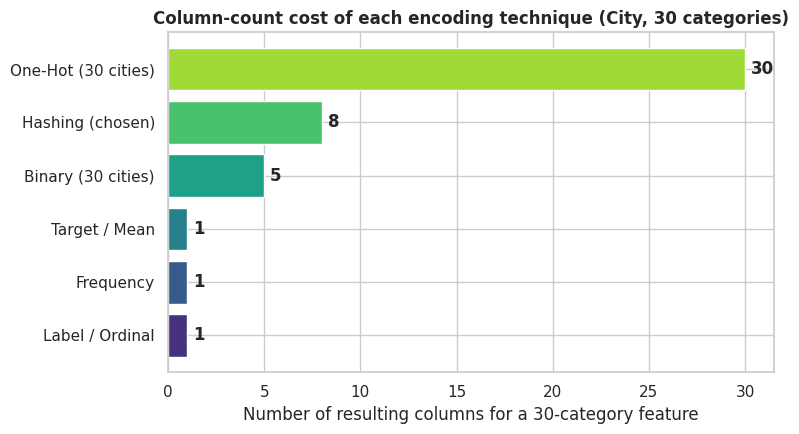

In [11]:
column_cost = pd.Series({
    'Label / Ordinal': 1,
    'Frequency': 1,
    'Target / Mean': 1,
    'Binary (30 cities)': city_binary.shape[1],
    'Hashing (chosen)': city_hashed.shape[1],
    'One-Hot (30 cities)': df['City'].nunique(),
}).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = sns.color_palette('viridis', len(column_cost))
ax.barh(column_cost.index, column_cost.values, color=colors)
ax.set_xlabel('Number of resulting columns for a 30-category feature')
ax.set_title('Column-count cost of each encoding technique (City, 30 categories)', fontweight='bold', fontsize=12)
for i, v in enumerate(column_cost.values):
    ax.text(v + 0.3, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Key takeaways

| Technique | Output columns | Assumes order? | High-cardinality friendly? | Leakage risk |
|---|---|---|---|---|
| Label Encoding | 1 | No, but implies one | No | None |
| Ordinal Encoding | 1 | **Yes (explicit)** | No | None |
| One-Hot Encoding | 1 per category | No | **No** — explodes | None |
| Dummy (`drop_first`) | (categories - 1) | No | No | None |
| Frequency Encoding | 1 | No | **Yes** | Low |
| Target / Mean Encoding | 1 | No | **Yes** | **High if not smoothed / cross-fitted** |
| Binary Encoding | log2(categories) | No | **Yes** | None |
| Hashing Encoding | Fixed, chosen upfront | No | **Yes** | None (but collision noise) |

**Rule of thumb:**
- Ordered categories → **Ordinal**.
- Few categories, unordered, linear/distance-based model → **One-Hot** (or dummy).
- Many categories → **Frequency**, **Target** (smoothed!), **Binary**, or **Hashing**, depending on whether you want simplicity, predictive power, compactness, or production robustness to unseen categories, respectively.
- Tree-based models (Random Forest, XGBoost, LightGBM) tolerate **Label/Ordinal** encoding on nominal data reasonably well, since trees split on thresholds rather than treating the encoded integer as a true magnitude — but One-Hot or Target encoding is often still stronger.

**Continue to:** `label_onehot_encoding.ipynb` for a hands-on, applied example using `ColumnTransformer` inside a real train/test pipeline (the employees dataset), including how to correctly handle categories that only appear in the test set.

---
## Decision guide — pick in ten seconds

Answer two questions: **is the column ordered?** and **how many categories are there?**

| Ordered? | Categories | Use | Why |
|---|---|---|---|
| Yes (Low < Med < High) | any | **Ordinal encoding** with an explicit order | the numbers carry the real ranking |
| No | 2 | **Label / binary 0-1** | with two categories there's no false ordering to create |
| No | 3–15 | **One-hot** (`drop_first=True` for regression) | no invented order, still a manageable width |
| No | 15–50 | **Frequency** or **target** encoding | one-hot would add too many columns |
| No | 50+ (postcode, product ID) | **Target** (smoothed), **binary** or **hashing** | keeps the width sane |
| No, and it's a tree model | any | **Label encoding is fine** | trees split on values, so a false order does no harm |

**Two traps that cost marks**

1. **The dummy-variable trap.** With all one-hot columns present, any one is perfectly predictable from the
   others. Linear regression can't cope. `pd.get_dummies(df, drop_first=True)` fixes it. Tree models don't care.
2. **Target leakage.** Target encoding uses the answer column to build a feature. Compute it on the
   **training data only**, use smoothing, and apply the learned mapping to the test set — never fit it on the
   whole dataset before splitting.

**Say this in your answer:** *"`Region` is nominal with four levels, so I one-hot encoded it with
`drop_first=True` to avoid the dummy-variable trap. `Grade` is ordinal, so I mapped it to 1/2/3 to preserve
the ranking."* That single sentence demonstrates you understand the difference — which is the whole point of
the question.

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Label encode | `LabelEncoder().fit_transform(s)` |
| Label encode, pandas only | `s.astype('category').cat.codes` |
| Ordinal, explicit order | `s.map({'Low':1,'Med':2,'High':3})` |
| One-hot | `pd.get_dummies(df, columns=['Region'])` |
| Dummy (avoid the trap) | `pd.get_dummies(df, drop_first=True)` |
| 0/1 instead of True/False | `pd.get_dummies(..., dtype=int)` |
| One-hot, sklearn | `OneHotEncoder(handle_unknown='ignore')` |
| Frequency encode | `s.map(s.value_counts(normalize=True))` |
| Target encode | `s.map(df.groupby(s)['y'].mean())` |
| How many categories | `s.nunique()` |
| Rare categories → 'Other' | `s.where(s.map(vc) >= 10, 'Other')` |

### Adapting this in the exam

- 'Convert the categorical variables' → state nominal vs ordinal first, then pick accordingly.
- 'For a regression model' → one-hot with `drop_first=True`.
- 'The column has many unique values' → frequency or target encoding, and say why one-hot was rejected.

### Traps that cost marks

- Label encoding a nominal column invents an order the model will believe. Only safe for binary columns or tree models.
- `LabelEncoder` sorts alphabetically, so 'High'=0, 'Low'=1, 'Medium'=2 — the exact opposite of the real order. Use an explicit `.map()` for ordinal data.
- One-hot without `drop_first=True` creates perfect multicollinearity and breaks linear regression.
- Fitting an encoder on the whole dataset before the train/test split leaks information. Fit on train, transform test.
- A category present only in the test set crashes a fitted encoder — use `handle_unknown='ignore'`.
- `pd.get_dummies` returns True/False in current pandas. Add `dtype=int` if you need 0/1.